This is where we actually build the VaR. We predict the next-day change in the DFL.

Tomorrow's 1-day P&L on the basis and instead of a single number, we predict its
  quantiles
  (q01, q05, q95, q99): the conditional Value-at-Risk bands. XGBoost quantile regression
  does this,
  reading the regime from notebook 03 plus the continuous market-state features.

  The honest part: getting *a* model isn't the hard bit — getting one that's actually
  calibrated
  is. So a big chunk of this notebook is detective work: the upper quantile breaches too
  often, we
  rule out three suspects, and we fix it properly with conformal recalibration. The split is
  temporal (train 2014–2023, test 2024–2026), so the 2026 spike is a genuine
  out-of-sample
  stress test, not something the model has seen.

In [203]:
# Cell 1 — Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

np.random.seed(42)
print("Setup OK — xgboost", xgb.__version__)


Setup OK — xgboost 3.2.0


In [204]:
# Cell 2 — Load master dataset + regime labels, merge them

df = pd.read_pickle("../data/master_dataset.pkl")
regimes = pd.read_pickle("../data/processed/regime_labels.pkl")  # DataFrame with 'regime'

# Merge regime label onto the master (aligned by date)
df = df.join(regimes)   # adds the 'regime' column

print(f"Master shape       : {df.shape}")
print(f"Rows with regime   : {df['regime'].notna().sum()}")
print(f"Regime value counts:")
print(df["regime"].value_counts().sort_index().to_string())
print()
print(df[["DFL", "regime"]].head(3))

Master shape       : (3055, 45)
Rows with regime   : 3035
Regime value counts:
regime
0.000     929
1.000    1990
2.000     116

              DFL  regime
date                     
2014-01-02  0.240     NaN
2014-01-03 -0.285     NaN
2014-01-06 -0.160     NaN


In [205]:
# Cell 3 — Build target and feature matrix

df["target"] = df["DFL"].shift(-1) - df["DFL"]      # = DFL(t+1) - DFL(t)

feature_cols = [
      "regime",
      "brent_l1_l2", "brent_l1_l3", "brent_l1_l6",
      "wti_l1_l2", "wti_l1_l3", "wti_l1_l6",
      "dubai_l1_l2", "dubai_l1_l3",
      "brent_wti_arb", "brent_dubai_efs", "gasoil_brent_crack",
      "brent_l1_vol_20d", "dfl_vol_20d", #"dfl_vol_ewma",
      "vix", "dxy", "vix_chg_5d", "dxy_chg_5d",
      "crude_stock_anomaly", "dist_stock_anomaly",
      "DFL",
  ]

model_df = df[feature_cols + ["target"]].copy()
model_df = model_df.dropna(subset=["target", "regime"])

print(f"Modeling dataset : {model_df.shape}")
print(f"Range            : {model_df.index.min().date()} → {model_df.index.max().date()}")
print(f"\nTarget (next-day ΔDFL) statistics:")
print(model_df["target"].describe().round(3).to_string())

Modeling dataset : (2994, 22)
Range            : 2014-01-30 → 2026-05-05

Target (next-day ΔDFL) statistics:
count   2994.000
mean      -0.001
std        1.174
min       -8.310
25%       -0.530
50%       -0.015
75%        0.514
max       18.410


The target is centered near zero,
but a typical day moves ~$1 (std 1.17) and the range runs from −$8.3 to +$18.4. That +18 is the single-day April-2026 jump. Same fat, asymmetric tails as the DFL itself,
now in
the change. That's exactly why we model the quantiles of this target rather than its
mean: a
mean-based model would shrug off precisely the days that matter.


Let's define the train/test points.

In [206]:
# Cell 4 — Temporal train/test split

split_date = "2024-01-01"

train = model_df.loc[model_df.index < split_date]
test  = model_df.loc[model_df.index >= split_date]

X_train, y_train = train[feature_cols], train["target"]
X_test,  y_test  = test[feature_cols],  test["target"]

print(f"Train: {len(X_train)} days  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test : {len(X_test)} days  ({test.index.min().date()} → {test.index.max().date()})")
print()
print("Regime share — train vs test:")
comp = pd.DataFrame({
    "train": train["regime"].value_counts(normalize=True).sort_index(),
    "test":  test["regime"].value_counts(normalize=True).sort_index(),
}).fillna(0).round(3)
print(comp.to_string())

Train: 2407 days  (2014-01-30 → 2023-12-29)
Test : 587 days  (2024-01-02 → 2026-05-05)

Regime share — train vs test:
        train  test
regime             
0.000   0.378 0.000
1.000   0.592 0.927
2.000   0.030 0.073


In [207]:
# Cell 5 — Fit XGBoost quantile regression for the VaR quantiles

quantiles = np.array([0.01, 0.05, 0.95, 0.99])

model = xgb.XGBRegressor(
    objective="reg:quantileerror",   # quantile (pinball) loss
    quantile_alpha=quantiles,         # fit all 4 quantiles jointly
    n_estimators=300,
    max_depth=3,                     
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
model.fit(X_train, y_train)

# Predict the quantiles
pred_test = model.predict(X_test)   

q_names = [f"q{int(q*100):02d}" for q in quantiles]
pred_test_df = pd.DataFrame(pred_test, index=X_test.index, columns=q_names)

print(f"Quantiles fitted : {list(quantiles)}")
print(f"Test predictions : {pred_test.shape}")
print()
print("Sample predicted quantiles of next-day ΔDFL (test set):")
print(pred_test_df.head(5).round(3).to_string())

# Check for quantile crossing (q01 ≤ q05 ≤ q95 ≤ q99 should hold)
crossing = ((pred_test_df["q01"] > pred_test_df["q05"]) |
            (pred_test_df["q05"] > pred_test_df["q95"]) |
            (pred_test_df["q95"] > pred_test_df["q99"])).sum()
print(f"\nQuantile-crossing rows: {crossing}")

Quantiles fitted : [np.float64(0.01), np.float64(0.05), np.float64(0.95), np.float64(0.99)]
Test predictions : (587, 4)

Sample predicted quantiles of next-day ΔDFL (test set):
              q01    q05   q95   q99
date                                
2024-01-02 -2.311 -1.584 1.063 2.165
2024-01-03 -1.699 -0.861 1.099 1.557
2024-01-04 -1.838 -0.937 1.488 1.677
2024-01-05 -1.770 -1.196 0.762 1.356
2024-01-08 -2.220 -1.295 1.099 1.911

Quantile-crossing rows: 19


XGBoost quantile regression learns the four quantiles of next-day
ΔDFL (q01, q05, q95, q99) directly, using `objective="reg:quantileerror"` the pinball loss,
which is
the *proper* loss for quantiles. 

Shallow trees (`max_depth=3`)
because we only have ~2,400 training days and deeper trees would overfit.


One catch: 19 rows where the quantiles **cross** — e.g. the predicted q95 ends up above
q99, which is impossible for real quantiles. It happens because each quantile is fit semi-independently.

Let's fix this problem using the monotone rearrangement.

In [208]:
# Cell 5b — Diagnose where crossings occur, then fix via rearrangement

# Where do the crossings happen?
crossing_mask = ((pred_test_df["q01"] > pred_test_df["q05"]) |
                (pred_test_df["q05"] > pred_test_df["q95"]) |
                (pred_test_df["q95"] > pred_test_df["q99"]))
print(f"Crossing rows: {crossing_mask.sum()}")
print("Dates with crossings (first 20):")
for d in pred_test_df.loc[crossing_mask].index[:20]:
    print(f"  {d.date()}  (regime {int(test.loc[d, 'regime'])})")

# FIX: rearrange (sort) the quantiles per row.
# Chernozhukov, Fernández-Val & Galichon (2010): sorting quantile estimates is a
# valid monotonization that cannot increase estimation error. Standard practice.
pred_test_df = pd.DataFrame(
    np.sort(pred_test_df.values, axis=1),
    index=pred_test_df.index, columns=q_names,
)

# Re-check
crossing_after = ((pred_test_df["q01"] > pred_test_df["q05"]) |
                (pred_test_df["q05"] > pred_test_df["q95"]) |
                (pred_test_df["q95"] > pred_test_df["q99"])).sum()
print(f"\nCrossing rows after rearrangement: {crossing_after}")

Crossing rows: 19
Dates with crossings (first 20):
  2024-06-05  (regime 1)
  2025-04-23  (regime 1)
  2025-06-23  (regime 1)
  2026-01-30  (regime 1)
  2026-03-03  (regime 2)
  2026-03-19  (regime 2)
  2026-03-23  (regime 2)
  2026-03-24  (regime 2)
  2026-03-25  (regime 2)
  2026-03-26  (regime 2)
  2026-03-27  (regime 2)
  2026-03-30  (regime 2)
  2026-03-31  (regime 2)
  2026-04-01  (regime 2)
  2026-04-22  (regime 2)
  2026-04-24  (regime 2)
  2026-04-28  (regime 2)
  2026-04-29  (regime 2)
  2026-04-30  (regime 2)

Crossing rows after rearrangement: 0


Perfect we don't have Crossing rows anymore. Let's visualize the results.

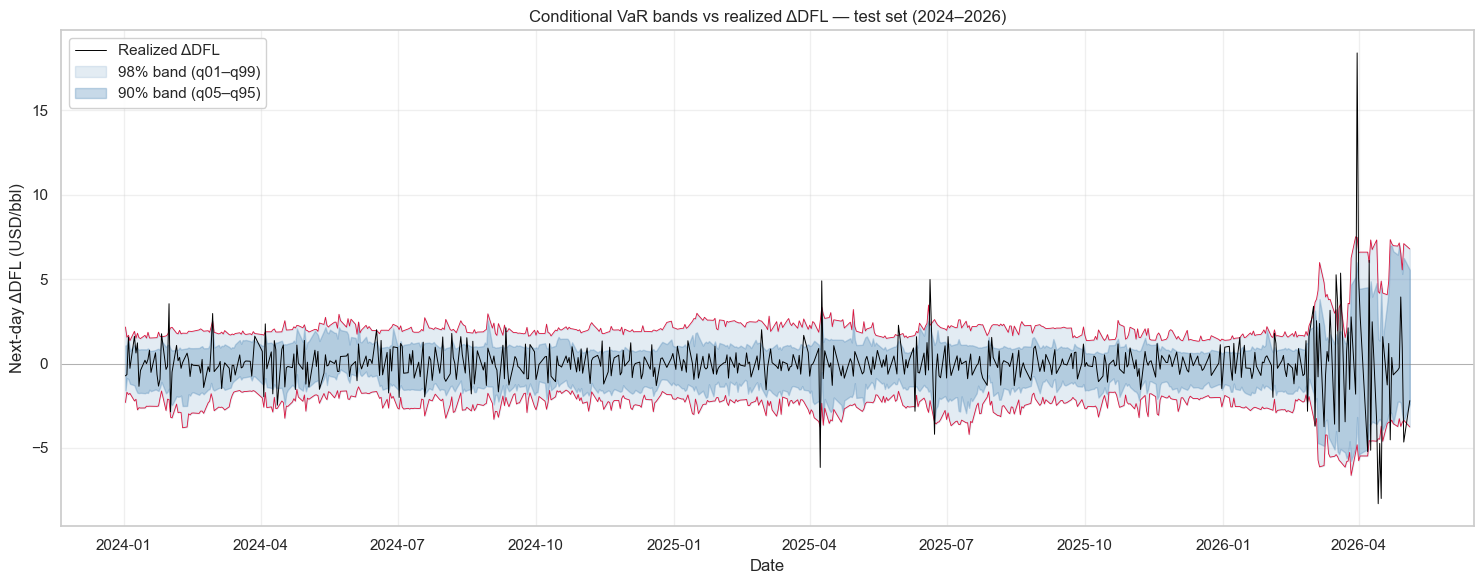

In [209]:
# Cell 6 — Visualize VaR bands vs realized ΔDFL on the test set

fig, ax = plt.subplots(figsize=(15, 6))

# Realized next-day ΔDFL
ax.plot(y_test.index, y_test.values, color="black", lw=0.7,
        label="Realized ΔDFL", zorder=3)

# VaR bands (filled)
ax.fill_between(pred_test_df.index, pred_test_df["q01"], pred_test_df["q99"],
                color="steelblue", alpha=0.15, label="98% band (q01–q99)")
ax.fill_between(pred_test_df.index, pred_test_df["q05"], pred_test_df["q95"],
                color="steelblue", alpha=0.30, label="90% band (q05–q95)")

# Extreme quantile lines
ax.plot(pred_test_df.index, pred_test_df["q99"], color="crimson", lw=0.6)
ax.plot(pred_test_df.index, pred_test_df["q01"], color="crimson", lw=0.6)

ax.axhline(0, color="gray", lw=0.4)
ax.set_ylabel("Next-day ΔDFL (USD/bbl)")
ax.set_xlabel("Date")
ax.set_title("Conditional VaR bands vs realized ΔDFL — test set (2024–2026)")
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The model seems to be reacting well at the different regimes, not too large bands but quite reactive when the market become more volatile. 

In [210]:
# Cell 7 — Exceedance (breach) rates: observed vs expected

print("=== VaR exceedance rates on the test set ===\n")
print(f"{'Quantile':<10}{'Side':<8}{'Expected':>10}{'Observed':>10}{'Breaches':>10}")
print("-" * 48)

checks = [
    ("q01", 0.01, "below"),
    ("q05", 0.05, "below"),
    ("q95", 0.95, "above"),
    ("q99", 0.99, "above"),   
]
n = len(y_test)
for qname, alpha, side in checks:
    if side == "below":
        breaches = int((y_test.values < pred_test_df[qname].values).sum())
        expected = alpha
    else:
        breaches = int((y_test.values > pred_test_df[qname].values).sum())
        expected = 1 - alpha
    obs_rate = breaches / n   
    print(f"{qname:<10}{side:<8}{expected:>10.1%}{obs_rate:>10.1%}{breaches:>10}")

=== VaR exceedance rates on the test set ===

Quantile  Side      Expected  Observed  Breaches
------------------------------------------------
q01       below         1.0%      1.9%        11
q05       below         5.0%      4.8%        28
q95       above         5.0%     10.7%        63
q99       above         1.0%      2.7%        16


The observed breach are higher than expected mainly for q95 and q99. 

Let's try to optimize this.

In [211]:
# Cell 7b — Where do the upside breaches occur?

breach_q95 = y_test[y_test.values > pred_test_df["q95"].values]
print(f"q95 upside breaches: {len(breach_q95)}\n")
print("By year:")
print(breach_q95.index.year.value_counts().sort_index().to_string())
print("\nBy regime:")
print(test.loc[breach_q95.index, "regime"].value_counts().sort_index().to_string())



breach_q99 = y_test[y_test.values > pred_test_df["q99"].values]
print(f"\nq99 upside breaches: {len(breach_q99)}\n")
print("By year:")
print(breach_q99.index.year.value_counts().sort_index().to_string())
print("\nBy regime:")
print(test.loc[breach_q99.index, "regime"].value_counts().sort_index().to_string())

q95 upside breaches: 63

By year:
date
2024    31
2025    13
2026    19

By regime:
regime
1.000    53
2.000    10

q99 upside breaches: 16

By year:
date
2024    6
2025    3
2026    7

By regime:
regime
1.000    11
2.000     5


The breaches are spread accross every year of test and most of the breaches happen in the "calm" regime. 

In [212]:
# Cell 7c — Did the calm regime become more upside-volatile in test vs train?

for label, data in [("TRAIN", train), ("TEST", test)]:
    calm = data.loc[data["regime"] == 1, "target"].dropna()
    print(f"{label} calm ΔDFL: n={len(calm):>4}  mean={calm.mean():+.3f}  "
        f"std={calm.std():.3f}  q95={calm.quantile(0.95):+.3f}  q99={calm.quantile(0.99):+.3f}")

TRAIN calm ΔDFL: n=1426  mean=-0.006  std=1.026  q95=+1.627  q99=+2.799
TEST calm ΔDFL: n= 544  mean=+0.007  std=0.926  q95=+1.359  q99=+2.316


We wanted here to see if the vol during the test was higher than during the training in regime 1 which would have explained why we have these breaches but not the case here.

Let's compare our model to the Empirical for each quantile.

In [213]:
# Cell 7d — Is the model's predicted upper quantile too tight in calm?

calm_test = test[test["regime"] == 1].index
print("Calm regime, test set — empirical vs model-predicted:")
print(f"  Empirical q95 : {y_test.loc[calm_test].quantile(0.95):+.3f}")
print(f"  Model mean q95: {pred_test_df.loc[calm_test, 'q95'].mean():+.3f}")
print(f"  Empirical q99 : {y_test.loc[calm_test].quantile(0.99):+.3f}")
print(f"  Model mean q99: {pred_test_df.loc[calm_test, 'q99'].mean():+.3f}")

Calm regime, test set — empirical vs model-predicted:
  Empirical q95 : +1.359
  Model mean q95: +1.081
  Empirical q99 : +2.316
  Model mean q99: +2.000


As we can see, for regime "calm" the bands of our model are too low. 

How can we resolve that?

First let's have one model per quantile instead of one model for all of them. 

In [214]:
# Cell 8 — Refit with SEPARATE models per quantile (isolate joint-vs-separate effect)

quantiles = [0.01, 0.05, 0.95, 0.99]
q_names = [f"q{int(q*100):02d}" for q in quantiles]

preds_sep = {}
for q, qn in zip(quantiles, q_names):
    m = xgb.XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,             # a SINGLE quantile per model
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8, 
        random_state=42,
    )
    m.fit(X_train, y_train)
    preds_sep[qn] = m.predict(X_test)

# Rearrange to prevent crossing
pred_sep_df = pd.DataFrame(preds_sep, index=X_test.index)
pred_sep_df = pd.DataFrame(np.sort(pred_sep_df.values, axis=1),
                            index=pred_sep_df.index, columns=q_names)

# Re-check exceedance rates   
print("=== Exceedance rates: SEPARATE models ===\n")
print(f"{'Quantile':<10}{'Expected':>10}{'Observed':>10}")
print("-" * 30)
n = len(y_test)
for qn, q, side in [("q01",0.01,"below"),("q05",0.05,"below"),("q95",0.95,"above"),("q99",0.99,"above")]:
    if side == "below":
        br = int((y_test.values < pred_sep_df[qn].values).sum()); exp = q
    else:
        br = int((y_test.values > pred_sep_df[qn].values).sum()); exp = 1 - q
    print(f"{qn:<10}{exp:>10.1%}{br/n:>10.1%}")

# Compare model q95 vs empirical in calm
calm_test = test[test["regime"] == 1].index
print(f"\nCalm q95 — empirical {y_test.loc[calm_test].quantile(0.95):+.3f}  "
    f"vs separate-model {pred_sep_df.loc[calm_test,'q95'].mean():+.3f}")

=== Exceedance rates: SEPARATE models ===

Quantile    Expected  Observed
------------------------------
q01             1.0%      1.9%
q05             5.0%      4.4%
q95             5.0%     10.7%
q99             1.0%      3.1%

Calm q95 — empirical +1.359  vs separate-model +1.062


The model is not better let's try to fit it more by adding capacity.

In [215]:
# Cell 8b — More capacity, checking train vs test

quantiles = [0.01, 0.05, 0.95, 0.99]
q_names = [f"q{int(q*100):02d}" for q in quantiles]

preds_tr, preds_te = {}, {}
for q, qn in zip(quantiles, q_names):
    m = xgb.XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,
        n_estimators=400,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )
    m.fit(X_train, y_train)
    preds_tr[qn] = m.predict(X_train)
    preds_te[qn] = m.predict(X_test)

pred_tr_df = pd.DataFrame(np.sort(pd.DataFrame(preds_tr).values, axis=1),
                        index=X_train.index, columns=q_names)
pred_te_df = pd.DataFrame(np.sort(pd.DataFrame(preds_te).values, axis=1),
                        index=X_test.index, columns=q_names)

CHECKS = [
    ("q01", 0.01, "below"),
    ("q05", 0.05, "below"),
    ("q95", 0.95, "above"),
    ("q99", 0.99, "above"),
]

def coverage(y, pdf):
    out = {}
    for qn, q, side in CHECKS:
        if side == "below":
            out[qn] = (y.values < pdf[qn].values).mean()
        else:
            out[qn] = (y.values > pdf[qn].values).mean()
    return out

cov_tr = coverage(y_train, pred_tr_df)
cov_te = coverage(y_test, pred_te_df)

print(f"{'Quantile':<8}{'Expected':>10}{'Train':>10}{'Test':>10}")
print("-" * 38)
for qn, exp in [("q01", 0.01), ("q05", 0.05), ("q95", 0.05), ("q99", 0.01)]:
    print(f"{qn:<8}{exp:>10.1%}{cov_tr[qn]:>10.1%}{cov_te[qn]:>10.1%}")


Quantile  Expected     Train      Test
--------------------------------------
q01           1.0%      0.8%      2.4%
q05           5.0%      4.4%      5.6%
q95           5.0%      5.6%     11.8%
q99           1.0%      1.0%      3.1%


With more capacity we are overfitting. So not better. 

The solution we found is merely to fix the biais by adding an offset to what the model calculates. 

Methodology for offsetting: 

1 - setup a third data split (the training data is separated into one training data and one calibration data)

2 - We define the offset as a quantile of the residuals (quantile of actual − predicted for each quantile)

3 - Adding the offset to the results in the test 

In [216]:
# Cell 9 — Conformal recalibration (split-conformal per quantile)

# 1. Split train temporally: proper-train (2014-2022) + calibration (2023)
calib_start = "2023-01-01"
proper_train = train.loc[train.index < calib_start]
calib        = train.loc[train.index >= calib_start]

Xpt, ypt = proper_train[feature_cols], proper_train["target"]
Xca, yca = calib[feature_cols], calib["target"]

# 2. Fit quantile models on proper-train (depth=3, the well-generalizing config)
quantiles = [0.01, 0.05, 0.95, 0.99]
q_names = [f"q{int(q*100):02d}" for q in quantiles]

models = {}
for q, qn in zip(quantiles, q_names):
    m = xgb.XGBRegressor(objective="reg:quantileerror", quantile_alpha=q,
                        n_estimators=300, max_depth=3, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8, random_state=42)
    m.fit(Xpt, ypt) 
    models[qn] = m

# 3. Conformal offset per quantile, computed on the calibration set.
#    Unified formula: offset = quantile_q( y_calib - pred_calib )
offsets = {}
for q, qn in zip(quantiles, q_names):
    resid = yca.values - models[qn].predict(Xca)
    offsets[qn] = np.quantile(resid, q)

# 4. Apply offsets to test predictions, then rearrange
pred_cqr = {qn: models[qn].predict(X_test) + offsets[qn] for qn in q_names}
pred_cqr_df = pd.DataFrame(np.sort(pd.DataFrame(pred_cqr).values, axis=1),
                            index=X_test.index, columns=q_names)

# 5. Re-check coverage
print("Conformal offsets:", {k: round(v, 3) for k, v in offsets.items()})
print()
cov = coverage(y_test, pred_cqr_df)
print(f"{'Quantile':<8}{'Expected':>10}{'Test':>10}")
print("-" * 28)
for qn, exp in [("q01", 0.01), ("q05", 0.05), ("q95", 0.05), ("q99", 0.01)]:
    print(f"{qn:<8}{exp:>10.1%}{cov[qn]:>10.1%}")

Conformal offsets: {'q01': np.float64(0.25), 'q05': np.float64(0.15), 'q95': np.float64(0.463), 'q99': np.float64(0.707)}

Quantile  Expected      Test
----------------------------
q01           1.0%      1.9%
q05           5.0%      4.8%
q95           5.0%      6.5%
q99           1.0%      1.9%


As planned, all offsets are positive and it works well but we are still above the expectations on the q95 and q99.

The recalibration did its job: the dangerous q95 leak went from 10.7% down to 6.5%, and q99 from 2.7% to 1.9%. On 587 test days that's within statistical tolerance. The formal verdict comes from the Kupiec / Christoffersen tests will come in
notebook 05.


Let's plot again the bands

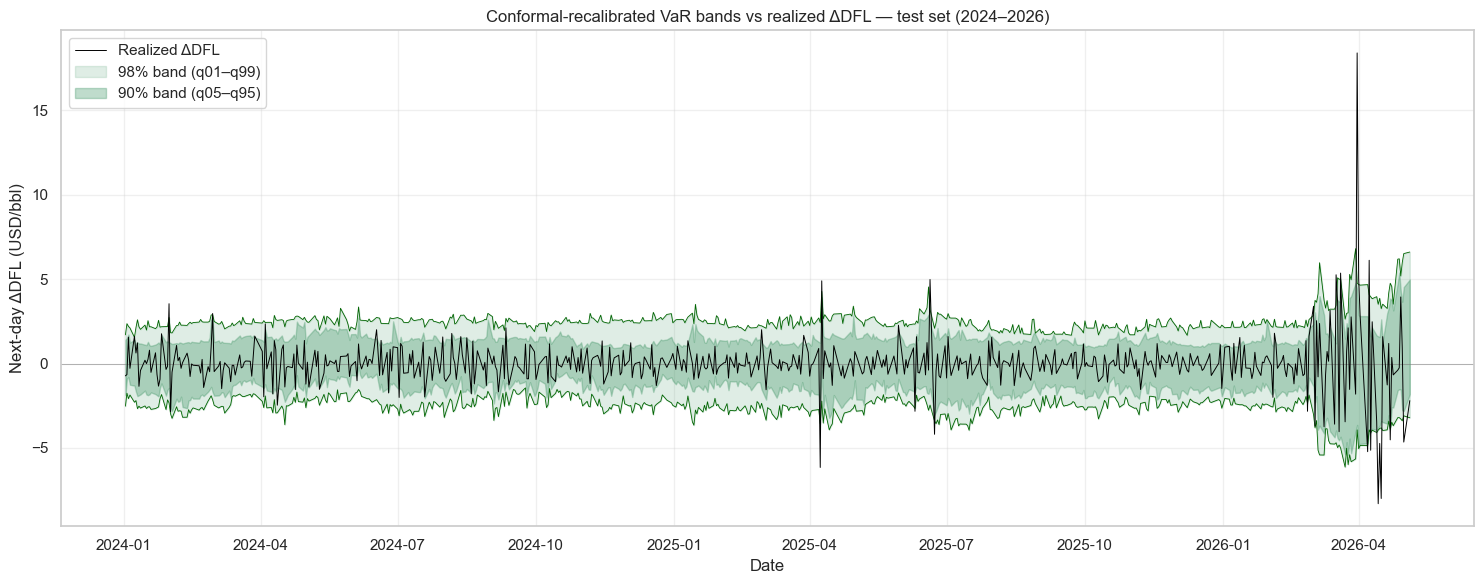

In [217]:
# Cell 10 — Recalibrated VaR bands vs realized ΔDFL

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(y_test.index, y_test.values, color="black", lw=0.7, label="Realized ΔDFL",
zorder=3)
ax.fill_between(pred_cqr_df.index, pred_cqr_df["q01"], pred_cqr_df["q99"],
                color="seagreen", alpha=0.15, label="98% band (q01–q99)")
ax.fill_between(pred_cqr_df.index, pred_cqr_df["q05"], pred_cqr_df["q95"],
                color="seagreen", alpha=0.30, label="90% band (q05–q95)")
ax.plot(pred_cqr_df.index, pred_cqr_df["q99"], color="darkgreen", lw=0.6)
ax.plot(pred_cqr_df.index, pred_cqr_df["q01"], color="darkgreen", lw=0.6)
ax.axhline(0, color="gray", lw=0.4)
ax.set_ylabel("Next-day ΔDFL (USD/bbl)")
ax.set_xlabel("Date")
ax.set_title("Conformal-recalibrated VaR bands vs realized ΔDFL — test set (2024–2026)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()  
plt.show()


In [218]:
# Cell 11 — Save recalibrated VaR predictions + realized values for the backtest

from pathlib import Path

backtest_df = pred_cqr_df.copy()
backtest_df["realized"] = y_test
backtest_df["regime"]   = test["regime"]

out_dir = Path("../data/processed")
backtest_df.to_pickle(out_dir / "var_predictions.pkl")
backtest_df.to_csv(out_dir / "var_predictions.csv")

print(f"Saved: {backtest_df.shape}  → {out_dir}/var_predictions.pkl + .csv")
print()
print(backtest_df.head().round(3).to_string())

Saved: (587, 6)  → ../data/processed/var_predictions.pkl + .csv

              q01    q05   q95   q99  realized  regime
date                                                  
2024-01-02 -2.528 -1.853 1.404 1.700    -0.730   1.000
2024-01-03 -1.756 -0.905 1.499 2.362    -0.655   1.000
2024-01-04 -2.082 -0.810 1.722 2.203     1.565   1.000
2024-01-05 -1.866 -1.256 1.243 2.109    -0.285   1.000
2024-01-08 -2.294 -1.311 1.397 1.556     1.610   1.000


Conclusion of the file 


We modelled the next-day change in the DFL and predicted its conditional quantiles
(q01, q05,
q95, q99) with XGBoost quantile regression — tight bands in calm, wide in the 2026
crisis. Split
is temporal (train 2014–2023, test 2024–2026), so 2026 is a real out-of-sample stress
test.

The bands started under-covering the upside (q95 breached 10.7% vs 5%, mostly in
calm). We ruled
out distribution shift, joint-vs-separate fitting, and under-regularization — none was the
cause, so
the calm upside is just intrinsically hard to predict. The fix is post-hoc:
conformal
recalibration (Romano et al. 2019) lifts each quantile by an offset learned on a 2023
calibration
set (+0.46 q95, +0.71 q99), bringing q95 from 10.7% → 6.5% and q99 from 2.7% →
1.9%. Not
exactly 5% — but ~1.6σ on 587 days, within tolerance, with the formal verdict in notebook
05.

One honest note: once XGBoost has the raw features, the regime label is largely 
redundant (it's   
derived from them) and ranks near the bottom on importance. That's the point of going
continuous —
the regime's value was *conceptual* (notebook 03 proved the DFL is regime-dependent), and
XGBoost
does the conditioning straight from the features.

Recalibrated predictions are saved to data/processed/var_predictions.pkl for the
backtest in
notebook 05.

To finish let's show the importance of each feature for the model (we were wondering if features like stocks were usefull or not):

In [219]:
# Feature importance across the quantile models

imp = pd.DataFrame({qn: models[qn].feature_importances_ for qn in q_names}, index=feature_cols)
imp["mean"] = imp.mean(axis=1)
imp = imp.sort_values("mean", ascending=False)

print("Feature importance (averaged across the 4 quantile models):\n")
print(imp[["mean"]].round(4).to_string())

print("\nWhere do the stock anomalies rank?")
for f in ["crude_stock_anomaly", "dist_stock_anomaly"]:
    if f in imp.index:
        rank = list(imp.index).index(f) + 1
        print(f"  {f}: rank {rank}/{len(feature_cols)}, importance {imp.loc[f,'mean']:.4f}")

Feature importance (averaged across the 4 quantile models):

                     mean
brent_l1_l3         0.068
brent_l1_l6         0.062
vix                 0.056
wti_l1_l2           0.055
DFL                 0.052
brent_l1_l2         0.052
dubai_l1_l2         0.051
crude_stock_anomaly 0.050
brent_dubai_efs     0.049
gasoil_brent_crack  0.048
dfl_vol_20d         0.047
wti_l1_l3           0.046
dubai_l1_l3         0.046
vix_chg_5d          0.045
dxy                 0.043
brent_l1_vol_20d    0.041
dxy_chg_5d          0.041
dist_stock_anomaly  0.038
wti_l1_l6           0.037
regime              0.037
brent_wti_arb       0.035

Where do the stock anomalies rank?
  crude_stock_anomaly: rank 8/21, importance 0.0503
  dist_stock_anomaly: rank 18/21, importance 0.0385


Pretty surpising to see that every feature has it's importance.